### Student Information
Name: 張家榕

Student ID: 110020036

GitHub ID: chiajungchang2003

---

### Instructions

### First Phase Submission

1. First: do the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) that considered as **phase 1 (from exercise 1 to exercise 15)**. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: follow the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** up **until phase 1**. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    -  Use [the new dataset](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/newdataset/Reddit-stock-sentiment.csv). The dataset contains a 16 columns including 'text' and 'label', with the sentiment labels being: 1.0 is positive, 0.0 is neutral and -1.0 is negative. You can simplify the dataset and use only the columns that you think are necessary. 
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.
    - Use this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output.


3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 10% of your grade.__
    - Generate meaningful **new data visualizations**. Refer to online resources and the Data Mining textbook for inspiration and ideas. 
    


4. Fourth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__

You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (September 28th 11:59 pm, Sunday)__. 

### Second Phase Submission 

**You can keep the answer for phase 1 for easier running and update the phase 2 on the same page.**

1. First: Continue doing the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) for **phase 2, starting from Finding frequent patterns**. Use the same master(.ipynb) file. Answer from phase 1 will not be considered at this stage. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: Continue from first phase and do the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** for phase 2, starting from Finding frequent pattern. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    - Continue using this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output. Use the same new dataset as in phase 1.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.

3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 20% of your grade.__
    - Use this file to answer.
    - Generate **TF-IDF features** from the tokens of each text. This will generating a document matrix, however, the weights will be computed differently (using the TF-IDF value of each word per document as opposed to the word frequency).  Refer to this Scikit-learn [guide](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) .
    - Implement a simple **Naive Bayes classifier** that automatically classifies the records into their categories. Use both the TF-IDF features and word frequency features to build two seperate classifiers. Note that for the TF-IDF features you might need to use other type of NB classifier different than the one in the Master Notebook. Comment on the differences and when using augmentation with feature pattern.  Refer to this [article](https://hub.packtpub.com/implementing-3-naive-bayes-classifiers-in-scikit-learn/).


4. Fourth: In the lab, we applied each step really quickly just to illustrate how to work with your dataset. There are somethings that are not ideal or the most efficient/meaningful. Each dataset can be handled differently as well. What are those inefficent parts you noticed? How can you improve the Data preprocessing for these specific datasets? __This part is worth 10% of your grade.__


5. Fifth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__


You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (October 19th 11:59 pm, Sunday)__. 

# Phase 1

In [5]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import plotly as py
import math
import PAMI
import umap
 
df=pd.read_csv("newdataset/Reddit-stock-sentiment.csv")
df.head()

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0
1,comment,2025-04-12 1:12:19,mmnu7v9,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Comfortable-Dog-8437,https://i.redd.it/7tl6puv9waue1.jpeg,-15,NaN,NaN,Stunt as in like why did they even make a big ...,0.177778,0.083333,1.0,"['Stunt', 'company', 'deal', 'place']",0.0
2,comment,2025-04-10 15:09:41,mmeevio,StockMarket,How do you feel about a sitting president maki...,Btankersly66,https://apnews.com/article/trump-truth-social-...,1,NaN,NaN,Seeing lots of red in the ticker.,0.000000,0.000000,0.0,['ticker'],0.0
3,post,2023-08-30 17:12:55,165kllm,stockstobuytoday,Who knows more? $VMAR,emiljenfn,https://www.reddit.com/r/stockstobuytoday/comm...,30,0.0,0.98,Vision Marine Technologies Inc. is rewriting t...,0.646970,0.216383,1.0,"['watercraft', 'skill', 'power', ']', 'feat', ...",1.0
4,comment,2025-04-11 14:48:05,mmkl6bw,StockMarket,The Trump administration is begging Xi Jinping...,Just-Big6411,https://edition.cnn.com/2025/04/10/politics/tr...,1,NaN,NaN,He didn’t say thank you.,0.000000,0.000000,0.0,[],-1.0


### Exercise 1

In [6]:
df["text"][0:3]

0                                     Calls on retards
1    Stunt as in like why did they even make a big ...
2                    Seeing lots of red in the ticker.
Name: text, dtype: object

### Exercise 2

In [8]:
df.loc[:10, ["text","sentiment"]]

,text,sentiment
0,Calls on retards,-1.0
1,Stunt as in like why did they even make a big ...,1.0
2,Seeing lots of red in the ticker.,0.0
3,Vision Marine Technologies Inc. is rewriting t...,1.0
4,He didn’t say thank you.,0.0
5,"Hoping to ejaculate in wet warm puss tonight, ...",1.0
6,Trump will respond to china increasing their t...,-1.0
7,Confirmed not a trap. Its been like this for p...,1.0
8,Am I the only one seeing the cup & handle brea...,1.0
9,HLGN is $10. Hurry and catch it now before it ...,0.0


### Exercise 3

In [9]:
df[df['subreddit']=='wallstreetbets'][::10][0:5]

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.0,-0.900,-1.0,[],-1.0
40,comment,2025-04-11 22:00:36,mmmyq7m,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,InstructionNo4546,https://www.reddit.com/r/wallstreetbets/commen...,10,NaN,NaN,These China AI factory memes are pretty good. ...,0.8,0.475,1.0,"['factory', 'time', 'AI', 'China AI', 'China',...",0.0
96,comment,2025-04-12 2:05:07,mmo2f48,wallstreetbets,Someone post the hotline please.,Rosie3435,https://i.redd.it/tcfuu97p7bue1.jpeg,1,NaN,NaN,200k loss in a month.. haha,0.3,0.200,1.0,"['..', 'month', 'loss', 'haha']",-1.0
183,comment,2025-04-11 22:45:45,mmn6eil,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,NonsensicalWorries,https://www.reddit.com/r/wallstreetbets/commen...,13,NaN,NaN,My resume isn't even read by companies anymore...,0.0,0.000,0.0,['resume'],-1.0
227,comment,2025-04-11 20:25:56,mmmh2t3,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,VisualMod,https://www.reddit.com/r/wallstreetbets/commen...,9,NaN,NaN,#Ban Bet Lost\r\n\r\n/u/Local-Wall-4359 made a...,0.4,0.800,1.0,"['Ban', 'Lost', '/u/Local-Wall-4359', 'WSB', '...",0.0


### Exercise 4

In [10]:
import helpers.data_mining_helpers as dmh
df.isnull().apply(lambda x: dmh.check_missing_values(x),axis=1)

0      (The amoung of missing records is: , 2)
1      (The amoung of missing records is: , 2)
2      (The amoung of missing records is: , 2)
3      (The amoung of missing records is: , 0)
4      (The amoung of missing records is: , 2)
                        ...                   
842    (The amoung of missing records is: , 2)
843    (The amoung of missing records is: , 2)
844    (The amoung of missing records is: , 0)
845    (The amoung of missing records is: , 2)
846    (The amoung of missing records is: , 2)
Length: 847, dtype: object

In [11]:
df.isnull().apply(lambda x: dmh.check_missing_values(x))

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:
1,0,0,0,0,0,0,0,0,783,783,0,0,0,0,0,0


In [12]:
#dealing with duplicate data
df.duplicated()
sum(df.duplicated())

0

In [13]:
#data preprocessing
df_sample = df.sample(n=200, random_state=1)
df_sample.head()

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
774,comment,2025-04-11 22:42:04,mmn5shb,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,exposed_anus,https://www.reddit.com/r/wallstreetbets/commen...,10,NaN,NaN,$REIT $ARD,0.000000,0.000000,0.0,"['REIT', 'ARD']",-1.0
375,comment,2025-04-10 16:52:24,mmezojg,StockMarket,How do you feel about a sitting president maki...,Xerio_the_Herio,https://apnews.com/article/trump-truth-social-...,2,NaN,NaN,Money and power go together... it's sick in th...,0.857143,-0.714286,-1.0,"['context', 'power', 'Money']",-1.0
185,comment,2021-02-01 14:26:09,gllndl3,stocks,"It's fucking awful seeing the ""Silver"" misinfo...",[deleted],https://www.reddit.com/r/stocks/comments/la34b...,2,NaN,NaN,Lmao what? Thought I was in WSB for a sec with...,0.783333,0.291667,1.0,"['fund', 'WSB', 'Silver', 'sec', 'trap', 'hedg...",0.0
464,comment,2025-04-11 21:20:06,mmmrf91,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,KahlVados,https://www.reddit.com/r/wallstreetbets/commen...,12,NaN,NaN,Has Xi called yet?\r\n\r\nCan someone check if...,0.000000,0.000000,0.0,"['phone', 'Xi', 'Has', 'someone']",-1.0
710,comment,2025-04-11 12:37:01,mmjx5qq,stocks,Is the market in complete denial right now?,MrRikleman,https://www.reddit.com/r/stocks/comments/1jwo1...,2,NaN,NaN,Where we are currently seems like the Bear Ste...,0.470000,0.110000,1.0,"['sand', 'Bear', 'everyone', 'Stearns', 'head'...",-1.0


### Exercise 7

subreddit
stocks              274
StockMarket         250
stockstobuytoday    174
wallstreetbets      149
Name: count, dtype: int64


<Axes: title={'center': 'Distribution of Subreddit'}, xlabel='subreddit'>

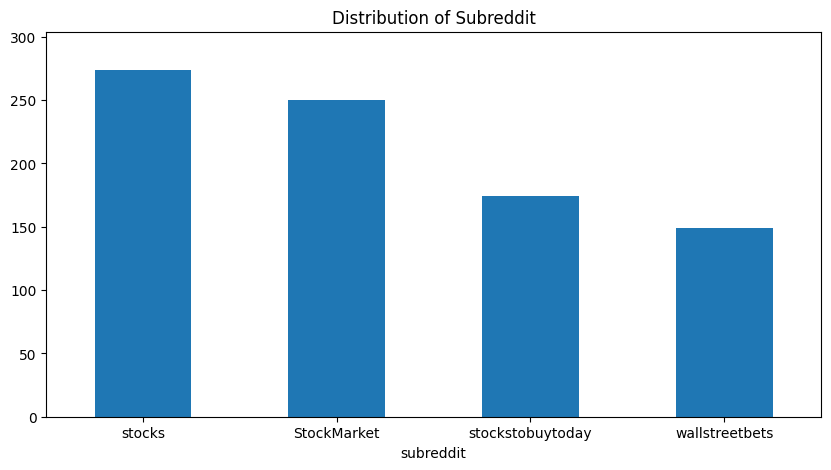

In [15]:
import matplotlib.pyplot as plt
%matplotlib inline
print(df.subreddit.value_counts())

#plot barchart for subreddit, excercise 7
df.subreddit.value_counts().plot(kind='bar',title='Distribution of Subreddit',ylim = [0, df.subreddit.value_counts().max()+30], rot = 0, figsize=(10,5))

### Exercise 8

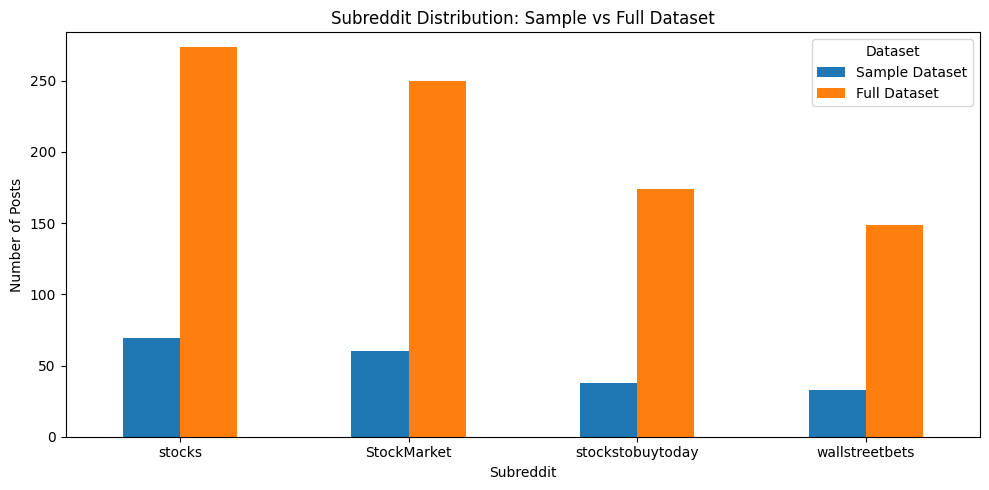

In [16]:
# Compute subreddit frequency distributions
sample_counts = df_sample['subreddit'].value_counts()
full_counts = df['subreddit'].value_counts()

# Combine into a single DataFrame and align indices
subreddit_counts = (
    pd.DataFrame({
        'Sample Dataset': sample_counts,
        'Full Dataset': full_counts
    })
    .fillna(0)
    .astype(int)
)

# Plot comparison bar chart
ax = subreddit_counts.plot(
    kind='bar',
    figsize=(10, 5),
    title='Subreddit Distribution: Sample vs Full Dataset',
    rot=0
)

# Adjust y-axis limits for visual padding
ax.set_ylim(0, subreddit_counts.values.max() + 10)

# Improve plot readability
ax.set_xlabel('Subreddit')
ax.set_ylabel('Number of Posts')
ax.legend(title='Dataset')

plt.tight_layout()
plt.show()


### Feature Creation

In [17]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [18]:
df['unigram'] = df['text'].apply(lambda x: dmh.tokenize_text(x))

In [25]:
from sklearn.feature_extraction.text import CountVectorizer
count_vectorizer = CountVectorizer()
df_counts=count_vectorizer.fit_transform(df['text'])

In [26]:
df_counts.shape

(847, 4346)

In [27]:
print(df_counts[0])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3 stored elements and shape (1, 4346)>
  Coords	Values
  (0, 692)	1
  (0, 2706)	1
  (0, 3248)	1


### Exercise 9

In [29]:
analyze=count_vectorizer.build_analyzer()
analyze("I am craving for a hawaiian pizza right now")

['am', 'craving', 'for', 'hawaiian', 'pizza', 'right', 'now']

In [30]:
analyze(df.text[0])

['calls', 'on', 'retards']

In [23]:
count_vectorizer.get_feature_names_out()[0:10]

array(['00', '000', '01378', '02', '027', '03', '06', '08', '10', '100'],
      dtype=object)

### Exercise 10

In [39]:
# we convert from sparse array to normal array
X_counts[5:10, 100:200].toarray()

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0,

In [40]:
row = X_counts[8]
nonzero_indices = row.nonzero()[1]
word = count_vect.get_feature_names_out()[nonzero_indices][1]
print(word)

the


In [32]:
count_vectorizer.get_feature_names_out()[0:100]

array(['00', '000', '01378', '02', '027', '03', '06', '08', '10', '100',
       '1000', '10000', '100k', '100x', '10k', '10ks', '10yr', '11',
       '116', '118', '12', '1242', '125', '12855584', '13', '14', '140',
       '145', '14th', '15', '150', '153', '15m', '16', '160', '17',
       '1700', '1728', '17th', '18', '186', '18630', '1870', '1934',
       '1945', '1947', '1953', '1961', '1969', '1973', '1974', '1981',
       '1992', '1999', '1k', '1m', '20', '200', '2007', '200k', '2011',
       '2012', '2017', '2021', '20211209', '2024', '2025', '2028', '2045',
       '208', '21', '22', '22rate', '23', '234', '235', '24', '25', '250',
       '25bps', '25k', '27', '28', '296895', '2c_books',
       '2c_wiki_recommendations', '2fapps', '2k', '2nd', '2s', '30',
       '300', '3000', '31', '31224', '31225', '31f', '33', '3306', '34'],
      dtype=object)

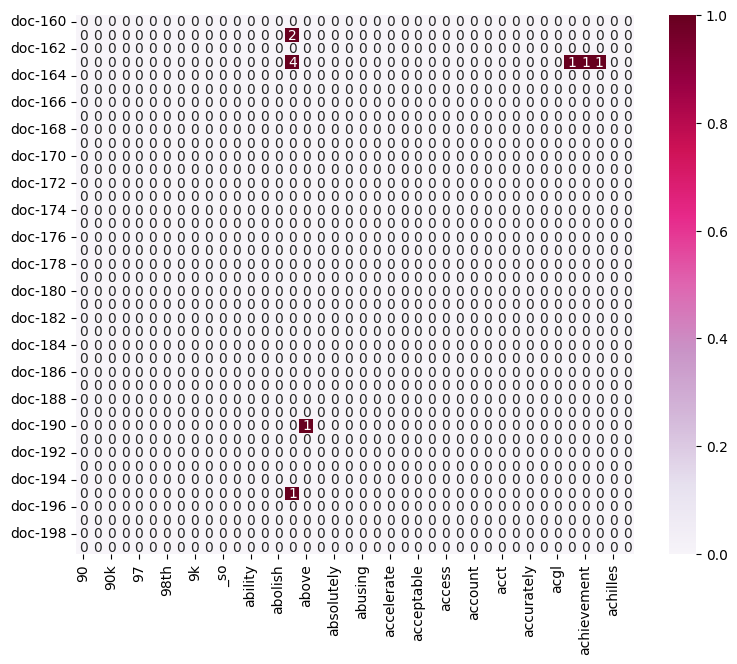

In [38]:
# plot a heap map to visualize
import seaborn as sns
# prepare a DataFrame for plotting
frequency_data = df_counts[0:40, 160:200].toarray()
columns = count_vect.get_feature_names_out()[160:200]
frequency_df = pd.DataFrame.from_records(frequency_data, columns=columns, index=[f"doc-{i}" for i in range(160, 200)])
# plot the heap map
plt.subplots(figsize=(9, 7))
ax = sns.heatmap(frequency_df,
                 cmap="PuRd",
                 vmin=0, vmax=1, annot=True)

### Exercise 11

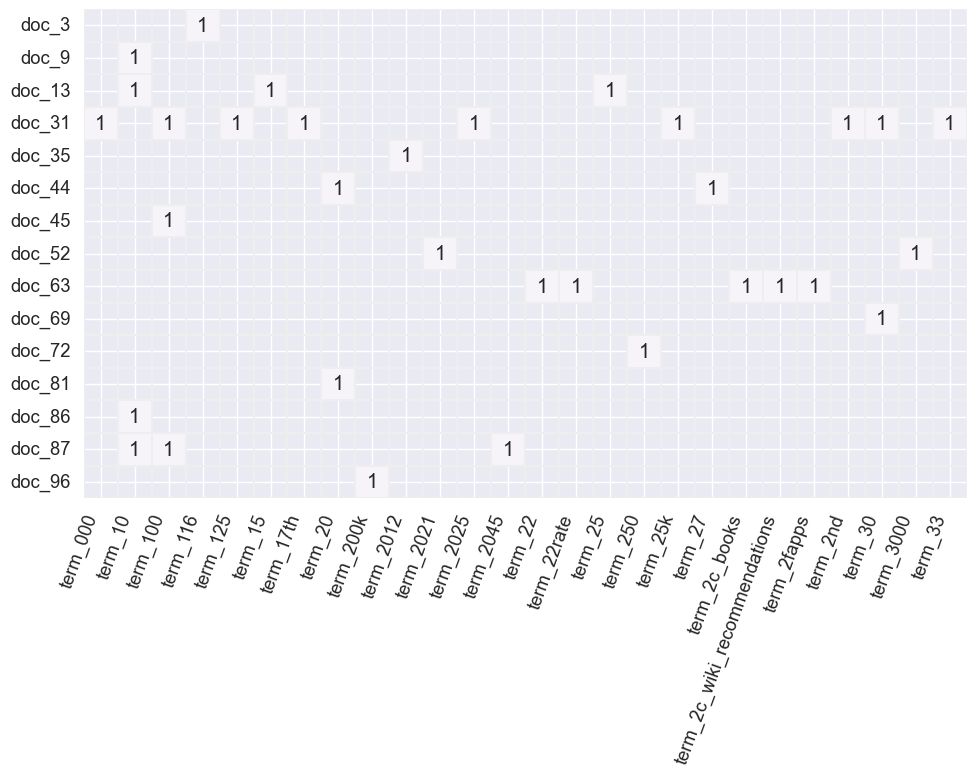

In [42]:
import numpy as np

my_df = (df_todraw > 0).astype(int)
# Remove rows and cols that are all zero
pruned_df = my_df.loc[my_df.any(axis=1), my_df.any(axis=0)]  

plt.figure(figsize=(10, 8))
sns.heatmap(pruned_df.replace(0, np.nan), cmap="PuRd", annot=True, fmt=".0f",
            cbar=False, linewidths=.2, linecolor="#eee")
sns.set(font_scale=1.2)
plt.xticks(rotation=70, ha="right"); plt.yticks(rotation=0); plt.tight_layout(); plt.show()

### Exercise 12

In [43]:
import numpy as np
import plotly.express as px

terms = count_vectorizer.get_feature_names_out()
term_frequencies = df_counts.sum(axis=0).A1

fig = px.bar(
    x=terms[:300],
    y=term_frequencies[:300],
    labels={'x': 'Term', 'y': 'Frequency'}
)
fig.update_layout(
    template='plotly_white',
    width=1800, height=500,
    xaxis_tickangle=90
)
fig.show()

### Exercise 13

In [44]:
import numpy as np
import plotly.express as px

# Extract vocabulary and compute total term frequencies
vocab = count_vectorizer.get_feature_names_out()
term_freq = df_counts.sum(axis=0).A1

# Keep only non-zero frequency terms and sort by frequency (descending)
nonzero_mask = term_freq > 0
vocab_nz = vocab[nonzero_mask]
freq_nz = term_freq[nonzero_mask]

TOP_K = 300
sorted_idx = np.argsort(freq_nz)[::-1][:TOP_K]

top_terms = vocab_nz[sorted_idx]
top_freq = freq_nz[sorted_idx]

# Visualization: Top-K most frequent terms
fig = px.bar(
    x=top_terms,
    y=top_freq,
    labels={'x': 'Term', 'y': 'Frequency'},
    title=f'Top {TOP_K} Most Frequent Terms (Non-zero Only)'
)

# Improve hover information
fig.update_traces(
    hovertemplate="<b>%{x}</b><br>Frequency: %{y}<extra></extra>"
)

fig.show()


### Exercise 15

In [45]:
import numpy as np
import plotly.express as px

# Extract vocabulary and aggregate term frequencies
vocab = count_vectorizer.get_feature_names_out()
term_freq = df_counts.sum(axis=0).A1
term_freq_log = np.log1p(term_freq)

# Keep only terms with non-zero frequency
nonzero_mask = term_freq > 0
vocab_nz = vocab[nonzero_mask]
freq_nz = term_freq[nonzero_mask]
freq_log_nz = term_freq_log[nonzero_mask]

# Sort by raw frequency (descending) and select top-K terms
TOP_K = 300
sorted_idx = np.argsort(freq_nz)[::-1][:TOP_K]

top_terms = vocab_nz[sorted_idx]
top_freq_log = freq_log_nz[sorted_idx]

# Plot log-transformed term frequencies
fig = px.bar(
    x=top_terms,
    y=top_freq_log,
    labels={
        'x': 'Term',
        'y': 'log(1 + Term Frequency)'
    },
    title=f'Top {TOP_K} Most Frequent Terms (Log-Transformed)'
)

# Improve hover information
fig.update_traces(
    hovertemplate="<b>%{x}</b><br>log(1 + freq): %{y:.3f}<extra></extra>"
)

fig.show()


### Generate meaningful new data visualization

In [46]:
!pip install python-louvain


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


### Word Co-occurrence Network

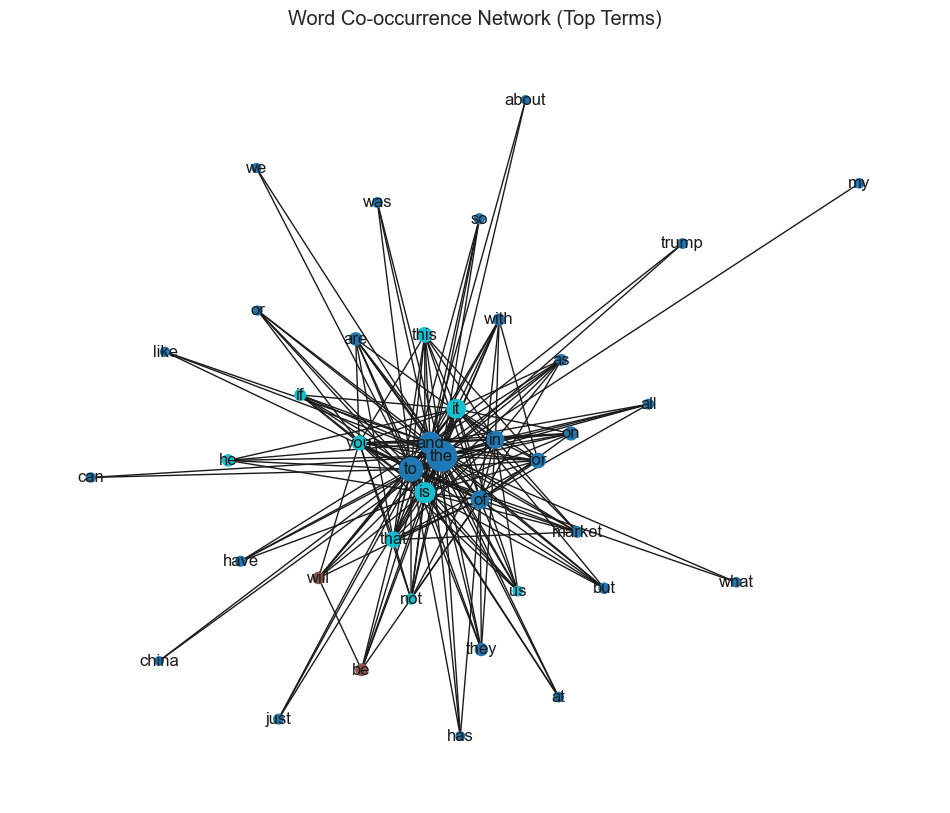

In [47]:
import networkx as nx
from itertools import combinations
from collections import Counter
import matplotlib.pyplot as plt
import community as community_louvain  # python-louvain

# choose top N terms overall or by sentiment
N = 40
term_freq = np.array(df_counts.sum(axis=0)).flatten()
top_idx = np.argsort(term_freq)[-N:]
top_terms = count_vect.get_feature_names_out()[top_idx]

# build cooccurrence (window=post-level)
sub_counts = df_counts[:, top_idx].toarray()
co_mat = np.dot(sub_counts.T, sub_counts)  # cooccurrence across documents
np.fill_diagonal(co_mat, 0)

# build graph with weights threshold
G = nx.Graph()
for i, t in enumerate(top_terms):
    G.add_node(t, freq=term_freq[top_idx[i]])
threshold = np.percentile(co_mat[co_mat>0], 75)  # keep stronger edges
for i,j in combinations(range(N), 2):
    w = co_mat[i,j]
    if w >= threshold:
        G.add_edge(top_terms[i], top_terms[j], weight=float(w))

# community detection
partition = community_louvain.best_partition(G, weight='weight')
pos = nx.spring_layout(G, k=0.35, iterations=50)
plt.figure(figsize=(12,10))
node_colors = [partition[n] for n in G.nodes()]
nx.draw_networkx(G, pos=pos, with_labels=True, node_size=[G.nodes[n]['freq']*0.5 for n in G.nodes()],
                 cmap=plt.cm.tab10, node_color=node_colors)
plt.title('Word Co-occurrence Network (Top Terms)')
plt.axis('off')
plt.show()


### PMI Heatmap

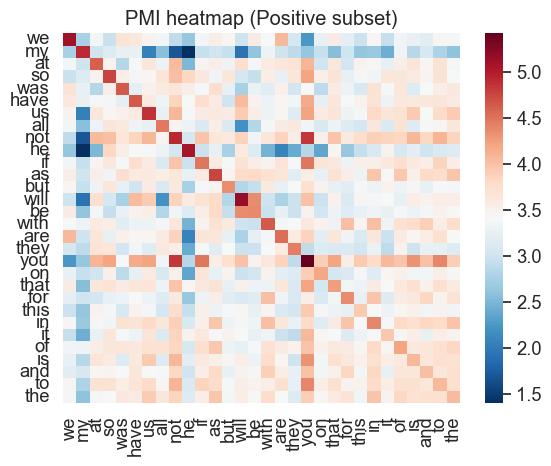

In [53]:
# Build co-occurrence counts for positive subset
from sklearn.feature_extraction.text import CountVectorizer
def pmi_matrix(df_subset, top_k=40):
    counts = count_vect.fit_transform(df_subset['text'])
    freqs = np.array(counts.sum(axis=0)).flatten()
    top_idx = np.argsort(freqs)[-top_k:]
    sub = counts[:, top_idx].toarray()
    co = np.dot(sub.T, sub)
    total = sub.sum()
    pmi = np.log((co * total + 1e-6) / (np.outer(sub.sum(axis=0), sub.sum(axis=0)) + 1e-6))
    return pmi, count_vect.get_feature_names_out()[top_idx]

pos_mask = X['sentiment_name'] == 'positive'

pmi_pos, terms_pos = pmi_matrix(X[pos_mask], top_k=30)
sns.heatmap(pmi_pos, xticklabels=terms_pos, yticklabels=terms_pos, cmap='RdBu_r')
plt.title('PMI heatmap (Positive subset)')
plt.show()


# Phase 2

In [ ]:
### Begin Assignment Here